Saving data_3hrs.csv to data_3hrs.csv
Data Awal:
   Timestamp (ms)  Humidity (%)  Temperature (°F)  Temperature (°C)
0               0         43.70             76.64             24.80
1            2000         45.26             76.56             24.76
2            4000         44.97             76.70             24.83
3            6000         45.96             78.22             25.68
4            8000         46.24             78.51             25.84
Index(['Timestamp (ms)', 'Humidity (%)', 'Temperature (°F)',
       'Temperature (°C)'],
      dtype='object')

=== Decision Tree ===
Akurasi: 0.9990740740740741
              precision    recall  f1-score   support

        HIGH       1.00      1.00      1.00         5
         LOW       1.00      1.00      1.00       584
      MEDIUM       1.00      0.50      0.67         2
         OFF       1.00      1.00      1.00       489

    accuracy                           1.00      1080
   macro avg       1.00      0.88      0.92      1080
w

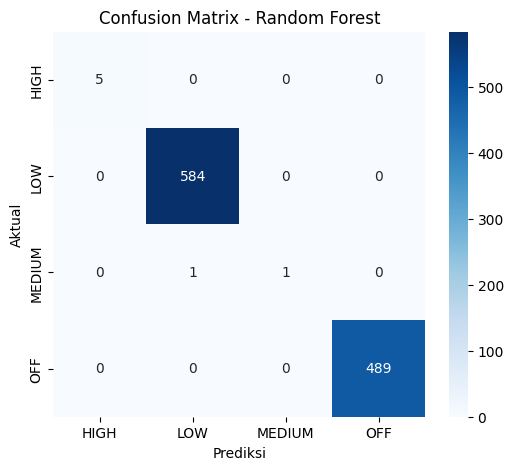

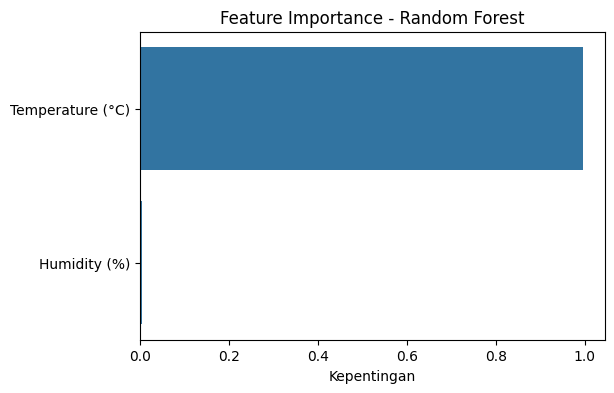

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


=== Contoh Prediksi ===
Decision Tree: Suhu 30°C, Hum 55% → MEDIUM (Kipas Kecepatan Sedang (60%))
Random Forest: Suhu 30°C, Hum 55% → MEDIUM (Kipas Kecepatan Sedang (60%))


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [9]:
# === Install library (sekali saja di Colab) ===
!pip install scikit-learn pandas joblib matplotlib seaborn

# === Import ===
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# === 1. Upload Dataset ===
uploaded = files.upload()

# Baca dataset (gunakan encoding aman)
df = pd.read_csv("data_3hrs.csv", encoding="latin-1")

print("Data Awal:")
print(df.head())
print(df.columns)

# === 2. Preprocessing & Labeling ===
X = df[['Temperature (°C)','Humidity (%)']]

def label_status(temp):
    if temp > 32:
        return "HIGH"
    elif 28 <= temp <= 32:
        return "MEDIUM"
    elif 25 <= temp < 28:
        return "LOW"
    else:
        return "OFF"

y = df['Temperature (°C)'].apply(label_status)

# === 3. Split Train/Test ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# === 4. Train Models ===
# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# === 5. Evaluasi ===
print("\n=== Decision Tree ===")
print("Akurasi:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

print("\n=== Random Forest ===")
print("Akurasi:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix (Random Forest)
cm = confusion_matrix(y_test, y_pred_rf, labels=rf_model.classes_)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=rf_model.classes_,
            yticklabels=rf_model.classes_)
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

# Feature Importance (Random Forest)
importances = rf_model.feature_importances_
features = ['Temperature (°C)','Humidity (%)']
plt.figure(figsize=(6,4))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Kepentingan")
plt.show()

# === 6. Simpan Model ===
joblib.dump(rf_model, "smartfan_rf_model.pkl")
joblib.dump(dt_model, "smartfan_dt_model.pkl")
files.download("smartfan_rf_model.pkl")
files.download("smartfan_dt_model.pkl")

# === 7. Contoh Prediksi User-Friendly ===
contoh = [[30, 55]]  # suhu=30, kelembapan=55%
pred_rf = rf_model.predict(contoh)[0]
pred_dt = dt_model.predict(contoh)[0]

status_kipas = {
    "HIGH": "Kipas Kecepatan Tinggi (100%)",
    "MEDIUM": "Kipas Kecepatan Sedang (60%)",
    "LOW": "Kipas Kecepatan Rendah (30%)",
    "OFF": "Kipas Mati"
}

print("\n=== Contoh Prediksi ===")
print(f"Decision Tree: Suhu {contoh[0][0]}°C, Hum {contoh[0][1]}% → {pred_dt} ({status_kipas[pred_dt]})")
print(f"Random Forest: Suhu {contoh[0][0]}°C, Hum {contoh[0][1]}% → {pred_rf} ({status_kipas[pred_rf]})")


In [7]:
%cd smart-app-dev-strawberrydev

/content/smart-app-dev-strawberrydev/smart-app-dev-strawberrydev


In [11]:
%%writefile train_smartfan_model.py

Writing train_smartfan_model.py


In [13]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
